In [2]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.ticker import MaxNLocator

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

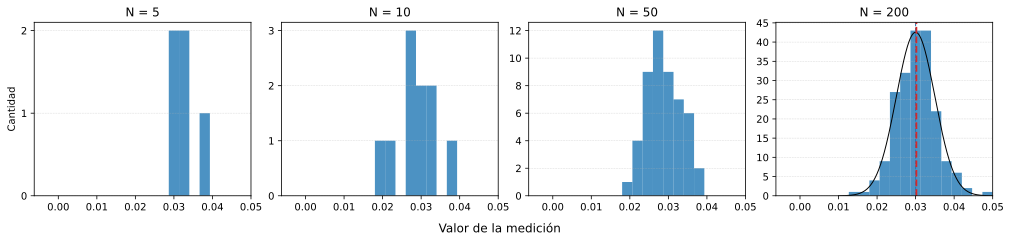

In [46]:
#| label: gaussian-noise
#| fig-cap: ""
#| fig-align: center

# Parámetros de la distribución
mu = 0.03          # Media [rad/s]
sigma = 0.005      # Desviación estándar [rad/s]

# Cantidad de muestras
N_values = [5, 10, 50, 200]

# Semilla para obtener siempre el mismo resultado
np.random.seed(42)

# Rango para los histogramas y la distribución teórica
xmin = mu - 4 * sigma
xmax = mu + 4 * sigma

# Ancho de los bins
bins = 15
bin_width = (xmax - xmin) / bins

# Valores de x para dibujar la Gaussiana
x = np.linspace(xmin, xmax, 500)

# Distribución Gaussiana
pdf = (
    1 / (sigma * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((x - mu) / sigma)**2)
)

# Crear los 4 subplots
fig, axes = plt.subplots(
    1, 4,
    figsize=(14, 3.5),
    sharex=True,
    # sharey=True
)

for i, (ax, N) in enumerate(zip(axes, N_values)):
    # Generar N muestras
    samples = np.random.normal(
        loc=mu,
        scale=sigma,
        size=N
    )

    # Media de las muestras
    sample_mean = np.mean(samples)

    # Histograma
    ax.hist(
        samples,
        bins=bins,
        range=(xmin, xmax),
        # density=True,
        alpha=0.8
    )
    
    if i == (len(N_values)-1):
        # Distribución Gaussiana teórica
        ax.plot(
            x,
            pdf * N * bin_width,    # PDF escalada a cantidad de muestras
            color="k",
            linewidth=1.0,
        )

        # Valor verdadero de la media
        ax.axvline(
            mu,
            linestyle='--',
            linewidth=1,
            label=r'$\mu$'
        )

        # Media de las muestras
        ax.axvline(
            sample_mean,
            color='tab:red',
            linestyle='--',
            linewidth=1.8,
            label=r'$\bar{x}$'
        )

    # Título
    ax.set_title(f'N = {N}')

    # Eje X
    # ax.set_xlabel('Velocidad angular [rad/s]')
    ax.set_xlim(-xmax/8, xmax)
    
    # Eje Y
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Cuadrícula
    ax.xaxis.grid(False)
    ax.grid(
        True,
        axis='y',
        linestyle='--',
        linewidth=0.5,
        alpha=0.5
    )

# Etiqueta del eje y solamente en el primer subplot
axes[0].set_ylabel('Cantidad')

fig.supxlabel('Valor de la medición', y=0.05)

# Una única leyenda
# axes[0].legend()

# plt.suptitle(
#     r'Muestras de una distribución $\mathcal{N}(\mu,\sigma^2)$',
#     y=1.05
# )

plt.tight_layout()
plt.show()